## Movie Recommend System

### Netflix Data Analysis

<p>This .ipynb file is related to Understanding of Netflix Data. </p>

#### Steps Included:
    1. Import Libraries
    2. Load the dataset
    3. Basic Information
    4. Missing Values
    5. Duplicate and Unique Values & Movie - Series Distribution 
    6. Genre Analysis
    7. Rating Analysis
    8. Runtime Analysis
    9. Top Directors
    10. Top Actors
    11. Years Analysis

#### Step 1 : Import the Libraries

In [1]:
# Import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)


### Step 2 : Load the Dataset

In [30]:
# Load the Dataset
df = pd.read_csv('../data/Netflix_data.csv')

df.head()

,imdbID,Title,Year,Type,Genre,Director,Writer,Actors,Plot,Language,Country,Runtime,Rated,Awards,imdbRating,imdbVotes,Poster
0,tt0107362,Last Action Hero,1993,movie,"Action, Adventure, Comedy",John McTiernan,"Zak Penn, Adam Leff, Shane Black","Arnold Schwarzenegger, F. Murray Abraham, Art ...",Young Danny Madigan is a huge fan of Jack Slat...,English,United States,130 min,PG-13,1 win & 16 nominations total,6.5,"173,615",https://m.media-amazon.com/images/M/MV5BZGU2NW...
1,tt21191806,Back in Action,2025,movie,"Action, Comedy",Seth Gordon,"Seth Gordon, Brendan O'Brien, Lillian Yu","Jamie Foxx, Cameron Diaz, McKenna Roberts",Former CIA spies Emily and Matt are pulled bac...,"English, Polish",United States,114 min,PG-13,1 nomination total,5.9,"65,501",https://m.media-amazon.com/images/M/MV5BMWQ4YW...
2,tt0318155,Looney Tunes: Back in Action,2003,movie,"Animation, Adventure, Comedy",Joe Dante,Larry Doyle,"Brendan Fraser, Jenna Elfman, Steve Martin",Bugs Bunny and Daffy Duck are up to their feud...,English,"Germany, United States",91 min,PG,10 nominations total,5.8,"41,828",https://m.media-amazon.com/images/M/MV5BNDU2Nm...
3,tt15600222,An Action Hero,2022,movie,"Action, Comedy, Crime",Anirudh Iyer,"Anirudh Iyer, Neeraj Yadav","Ayushmann Khurrana, Jaideep Ahlawat, Gautam Jo...",A murder accusation turns a movie star's own l...,Hindi,"India, United Kingdom",130 min,NaN,5 wins & 18 nominations,7.0,"32,711",https://m.media-amazon.com/images/M/MV5BNWUzNz...
4,tt0120633,A Civil Action,1998,movie,"Biography, Drama",Steven Zaillian,"Jonathan Harr, Steven Zaillian","John Travolta, Robert Duvall, Tony Shalhoub","Jan Schlichtmann, a tenacious lawyer, is addre...",English,United States,115 min,PG-13,Nominated for 2 Oscars. 5 wins & 10 nomination...,6.6,"32,240",https://m.media-amazon.com/images/M/MV5BMDgyND...


### Step 3 : Basic Information

In [31]:
# Basic Information about the Dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

# Summary Statistics
print("\nSummary Statistics:")
print(df.describe(include='all').T)


Dataset Shape: (3516, 17)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 3516 entries, 0 to 3515
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   imdbID      3516 non-null   str    
 1   Title       3516 non-null   str    
 2   Year        3516 non-null   str    
 3   Type        3516 non-null   str    
 4   Genre       3476 non-null   str    
 5   Director    2555 non-null   str    
 6   Writer      2542 non-null   str    
 7   Actors      3288 non-null   str    
 8   Plot        3159 non-null   str    
 9   Language    3387 non-null   str    
 10  Country     3479 non-null   str    
 11  Runtime     2812 non-null   str    
 12  Rated       1850 non-null   str    
 13  Awards      1307 non-null   str    
 14  imdbRating  3060 non-null   float64
 15  imdbVotes   3182 non-null   str    
 16  Poster      3152 non-null   str    
dtypes: float64(1), str(16)
memory usage: 2.5 MB
None

Summary Statistics:
         

### Step 4 : Missing Values

In [5]:
# Check Missing Values
print("\nMissing Values:")
missing_values = df.isnull().sum()

missing_values.sort_values(ascending=False)

missing_percentage = ((missing_values / len(df)) * 100).round(2)

print(missing_percentage.sort_values(ascending=False))


Missing Values:
Awards        62.83
Rated         47.38
Writer        27.70
Director      27.33
Runtime       20.02
imdbRating    12.97
Poster        10.35
Plot          10.15
imdbVotes      9.50
Actors         6.48
Language       3.67
Genre          1.14
Country        1.05
imdbID         0.00
Year           0.00
Type           0.00
Title          0.00
dtype: float64


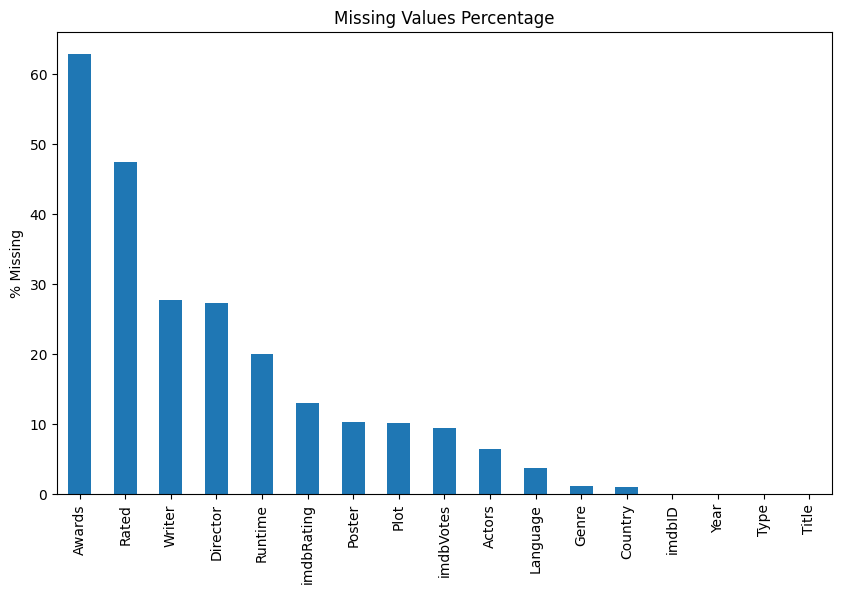

In [8]:
# Visualize Missing Values

missing_percentage.sort_values(ascending=False).plot(kind='bar')

plt.title("Missing Values Percentage")
plt.ylabel("% Missing")
plt.show()

### Step 5 : Duplicate and Unique Values & Movie - Series Distribution

In [11]:
# Check Duplicate Rows
print("Duplicated Rows:", df.duplicated().sum())

Duplicated Rows: 0


In [14]:
# check duplicate ImdbID
print("Duplicate IMDbs:", df['imdbID'].duplicated().sum())

Duplicate IMDbs: 0


In [15]:
# Unique ImdbIDs
print("Unique imdbIDs:", df['imdbID'].nunique())

Unique imdbIDs: 3516


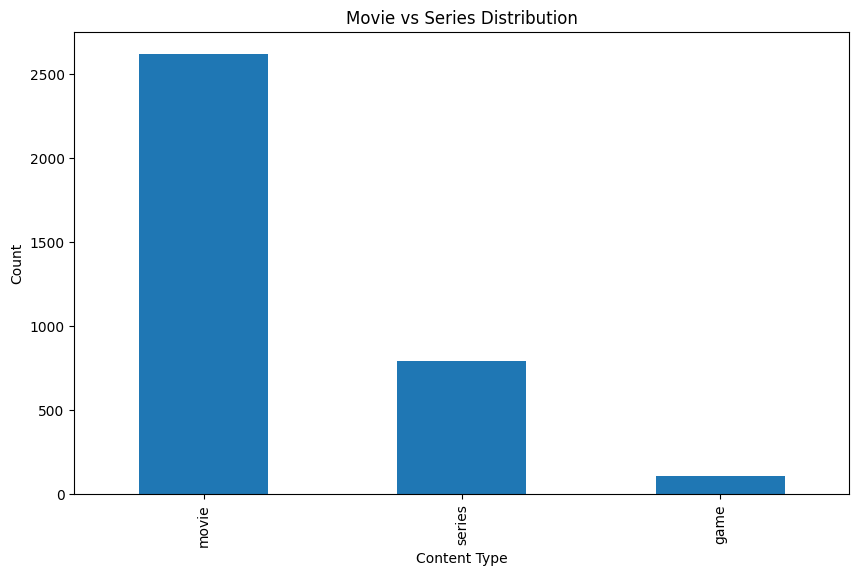

In [16]:
# Plot Movies Vs Series
df['Type'].value_counts().plot(kind='bar')

plt.title("Movie vs Series Distribution")

plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

### Step 6 : Genre Analysis

In [17]:
# Genre Analysis
genres = (df['Genre'].dropna().str.split(", ").explode())

genres.value_counts().head(20)

Genre
Comedy         1050
Drama           846
Action          765
Animation       592
Adventure       563
Documentary     563
Short           519
Horror          397
Crime           320
Romance         250
Fantasy         249
Sci-Fi          238
Thriller        209
Family          204
Mystery         180
History         136
Biography       124
Music           109
Musical         106
Sport            81
Name: count, dtype: int64

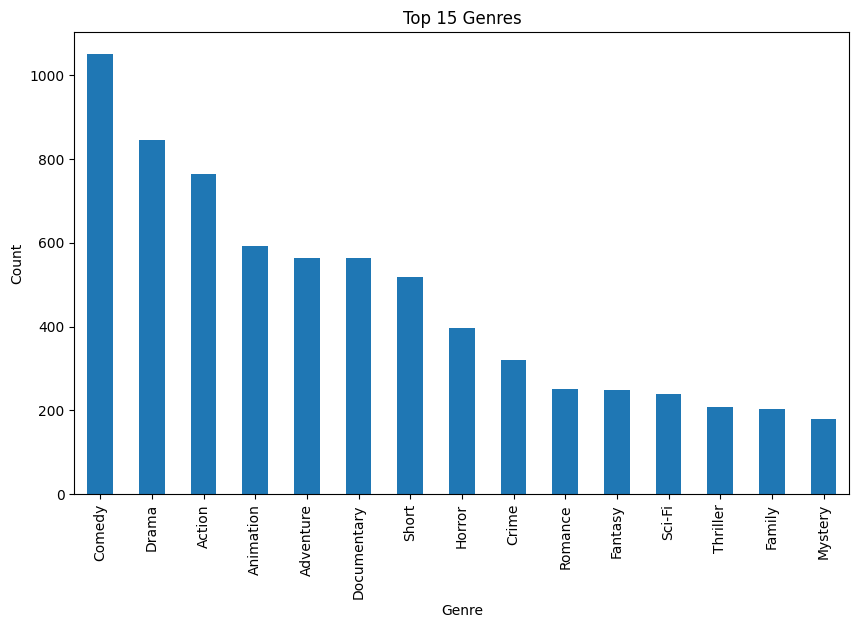

In [18]:
# Plot top 15 Genres
genres.value_counts().head(15).plot(kind='bar')

plt.title("Top 15 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

### Step 7 : Rating Analysis

In [19]:
# IMDb Rating Analysis
df['imdbRating'] = pd.to_numeric(df['imdbRating'], errors='coerce')

In [20]:
df['imdbRating'].describe()

count    3060.000000
mean        6.446438
std         1.442192
min         1.000000
25%         5.700000
50%         6.600000
75%         7.400000
max        10.000000
Name: imdbRating, dtype: float64

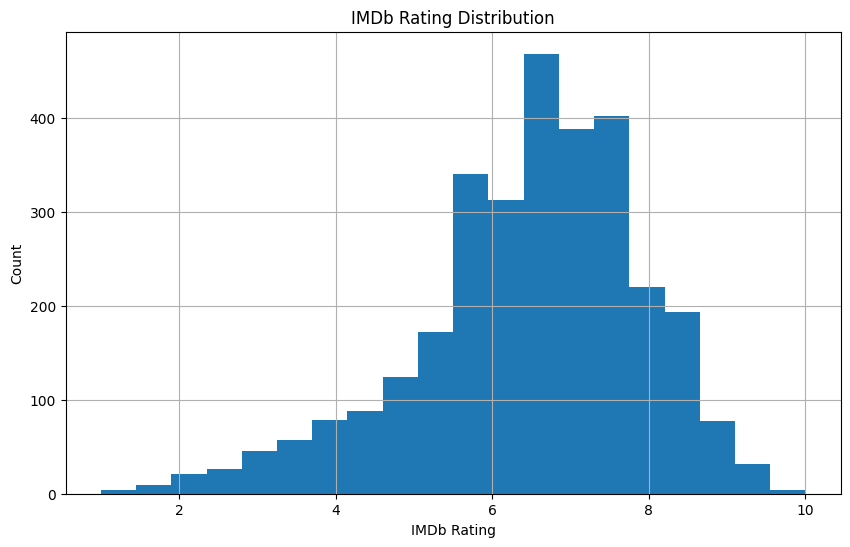

In [21]:
# Rating Distribution
df['imdbRating'].hist(bins=20)
plt.title("IMDb Rating Distribution")
plt.xlabel("IMDb Rating")
plt.ylabel("Count")
plt.show()

### Step 8 : Runtime Analysis

In [22]:
# Runtime Analysis
df['Runtime_Minutes'] = (df['Runtime'].str.extract(r"(\d+)"))
df['Runtime_Minutes'] = pd.to_numeric(df['Runtime_Minutes'], errors='coerce')

In [23]:
# Runtime Summary
df['Runtime_Minutes'].describe()

count    2812.000000
mean       77.497866
std        55.675589
min         1.000000
25%        44.000000
50%        84.000000
75%        99.000000
max       990.000000
Name: Runtime_Minutes, dtype: float64

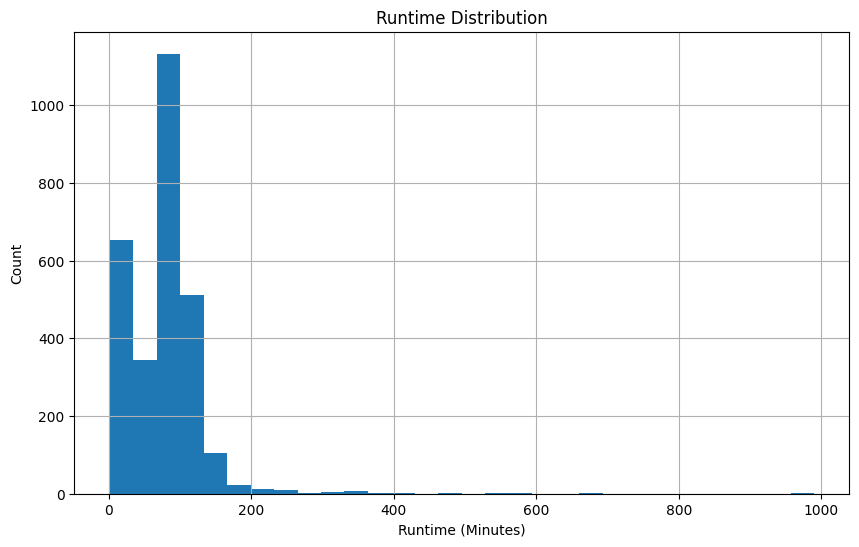

In [ ]:
# RunTime Distribution
df['Runtime_Minutes'].hist(bins=30)
plt.title("Runtime Distribution")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Count")
plt.show()

### Step 9 : Top Directors

In [25]:
# Top Directors
df['Director'].value_counts().head(20)

Director
Joel Gallen           15
Terry Ingram           6
Mark Jean              6
Jay Oliva              6
Sam Liu                6
Peter DeLuise          5
Keitarô Motonaga       5
Hironobu Sakaguchi     5
Glenn Amonitti         5
Robert Rodriguez       5
Shin'ya Ayabe          5
Naoyuki Tomomatsu      5
Woody Allen            4
Kenny Ortega           4
Tim Burton             4
J.J. Abrams            4
David Yates            4
George Lucas           4
Rick Morales           4
Ken Cunningham         4
Name: count, dtype: int64

### Step 10 : Top Actors

In [26]:
# Top Actors
actors = (df['Actors'].dropna().str.split(", ").explode())
actors.value_counts().head(20)

Actors
Kevin Conroy         23
Troy Baker           21
Laura Bailey         18
Dee Bradley Baker    16
Steve Blum           13
William Shatner      12
Mark Hamill          12
Jensen Ackles        12
Frank Welker         11
Jack Black           11
Will Friedle         10
Tom Kenny            10
David Carradine       9
Jackie Chan           9
Mel Blanc             9
Daniel Radcliffe      9
Christopher Lee       9
Grey Griffin          9
John DiMaggio         9
Rupert Grint          9
Name: count, dtype: int64

### Step 11 :  Year Analysis

In [27]:
# Year Analysis
df['Release_Year'] = df['Year'].astype(str).str.extract(r"(\d{4})")
df['Release_Year'] = pd.to_numeric(df['Release_Year'], errors='coerce')


<Axes: xlabel='Release_Year'>

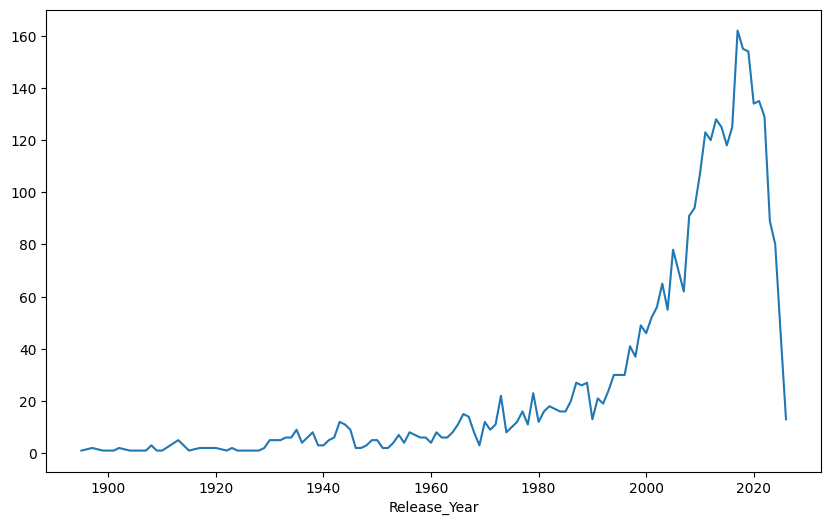

In [29]:
# Content Release By Year
df['Release_Year'].value_counts().sort_index().plot()

### Key Findings

1. Dataset contains 3516 records.
2. Total unique imdbIDs = `3516`
3. Duplicate imdbIDs = `0`
4. Most common genre :
    | Genre | Count |
    |------ | ----- |
    |Comedy  |       1050|
    |Drama    |       846|
    |Action    |      765|
    |Animation  |     592|
    |Adventure   |    563|
    |Documentary  |   563|
    |Short         |  519|
    |Horror         | 397|
    |Crime     |      320|
    |Romance    |     250|
    |Fantasy    |     249|
    |Sci-Fi     |     238|
    |Thriller   |     209|
    |Family     |     204|
    |Mystery    |     180|
    |History    |     136|
    |Biography  |     124|
    |Music      |     109|
    |Musical    |     106|
    |Sport      |      81|
5. Average IMDb rating = `6.44`
6. Most content belongs to Movie/Series? `Movie`
7. Missing values mainly occur in which columns:
    | Column |  Missing Percentage |
    | ------- | ----------------|
    |Awards  |      62.83|
    |Rated   |      47.38|
    |Writer  |      27.70|
    |Director |     27.33|
    |Runtime   |    20.02|
    |imdbRating |   12.97|
    |Poster     |   10.35|
    |Plot       |   10.15|
    |imdbVotes  |    9.50|
    |Actors     |    6.48|
    |Language   |    3.67|
    |Genre      |    1.14|
    |Country    |    1.05|
    |imdbID     |    0.00|
    |Year       |    0.00|
    |Type       |    0.00|
    |Title      |    0.00|